# Analyzing Public Perception of DeepSeek on Reddit: A Text-Based Exploration

# Introduction

The rise of DeepSeek and other large language models (LLMs) marks both a technological milestone and an opportunity to explore the geopolitical and cultural tensions in the global AI landscape. It is important to examine how predominantly English-speaking social media platforms, particularly Reddit, shape perceptions of AI models like DeepSeek (developed in China) and ChatGPT (developed in the U.S.). In this task, we ask the question: **What narratives emerge from Reddit communities’ discussions about DeepSeek, and how do these narratives reflect user perceptions and sentiment of AI innovation?**




# Overview
In this assignment, we will practice text analysis with the following guided tasks:

1) **Task 1**: Apply **K-means** clustering to identify hidden groups within the data

2) **Task 2**: Conduct **sentiment analysis** to examine user emotions toward "DeepSeek"

3) **Task 3**: Perform **topic modeling** to uncover latent topics regarding "DeepSeek"



# Data
Reddit offers an open and unfiltered platform where individuals share their perceptions about AI techniques, making it an ideal source of authentic data. We download subreddit posts on DeepSeek (r/DeepSeek_posts) from [arctic-shift](https://arctic-shift.photon-reddit.com/).

In [33]:
import os,datetime
import json, csv
import re
import pandas as pd
import numpy as np
from collections import Counter
import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

In [34]:
import nltk
from nltk.corpus import words
nltk.download('words')
english_words = set(words.words())

[nltk_data] Downloading package words to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package words is already up-to-date!


# Exploratory Data Analysis

In [35]:
def load_data(data_file):
    """
    Load original data from jsonl file, clean the data, and convert to a dataframe
    """

    # Step 1: Read json file, store as list of dicts
    posts_lst = []
    with open(data_file, 'r') as file:
        for line in file:
            posts_lst.append(json.loads(line))

    # Step 2: Extract fields that contain key information
    fields_to_extract = ['permalink', 'created_utc', 'selftext', 'title']

    # Step 3: Store the extracted information in a Dataframe
    extracted_data = [{k: d[k] for k in fields_to_extract if k in d} for d in posts_lst]
    df = pd.DataFrame(extracted_data)

    # Step 4: Complete each field of the dataframe
    df['permalink'] = 'https://old.reddit.com' + df['permalink']
    # Convert the unix timestamp to readable date
    df['date'] = df['created_utc'].apply(lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d'))
    del df['created_utc']

    # Step 5: Remove rows with missing values
    df.dropna(how = 'any', inplace=True)
    df = df[df['selftext'] != '[removed]']
    df.rename(columns={'selftext':'post'}, inplace=True)

    # Step 6: Convert dtype: object to string
    df = df.convert_dtypes()

    return df

In [36]:
def clean_text(text):
    '''
    Cleans the input text by removing URLs, HTML tags, mentions, hashtags,
    punctuation, special characters, newlines, and extra spaces.

    Input:
        text: a string containing raw text.
    Output:
        cleaned_text: a string with cleaned text.
    '''
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions (@username) and hashtags (#hashtag)
    text = re.sub(r'[@#]\w+', '', text)
    # Remove punctuation and special characters, replace with space
    text = re.sub(r'[^\w\s]', ' ', text)
    # Replace newlines with spaces
    text = text.replace('\n', ' ')
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing spaces
    text = text.strip()

    # Remove non-English words
    text = ' '.join(word for word in text.split() if word.lower() in english_words)

    return text

In [37]:
# load and clean the post
df_post = load_data('./r_DeepSeek_posts.jsonl')
df_post['post'] = df_post['post'].apply(lambda x: clean_text(x))
df_post.shape

(7051, 4)

In [38]:
# check the first 5 rows of the dataframe
df_post.head()

,permalink,post,title,date
0,https://old.reddit.com/r/DeepSeek/comments/1do...,,What's the max tokens for deepseek-coder-v2?,2024-06-25
1,https://old.reddit.com/r/DeepSeek/comments/1eo...,Seriously super factual and level performance,DeepSeek Coder V2 is a beast!,2024-08-10
2,https://old.reddit.com/r/DeepSeek/comments/1fd...,anyone tried to get it working in Dev I m gett...,Integrating with Claude-Dev,2024-09-10
3,https://old.reddit.com/r/DeepSeek/comments/1fw...,I have a question that i cant seem to find yet...,How to simultaneously complete a LLMs workload...,2024-10-04
4,https://old.reddit.com/r/DeepSeek/comments/1gc...,I was chatting through coder but today upon a ...,What happened to Coder DeepSeek?,2024-10-26


In [39]:
# check the words counts of the posts
df_post['length'] = df_post['post'].apply(lambda x: len(x))
df_post['length'].describe()

count     7051.000000
mean       277.872075
std        963.601044
min          0.000000
25%          0.000000
50%         34.000000
75%        204.000000
max      26991.000000
Name: length, dtype: float64

In [40]:
# remove samples with post length = 0, almost half of the samples are removed
df_post = df_post[df_post['length'] != 0]
df_post.shape

(3907, 5)

Text(0.5, 1.0, 'Distribution of Word Counts in Each Post')

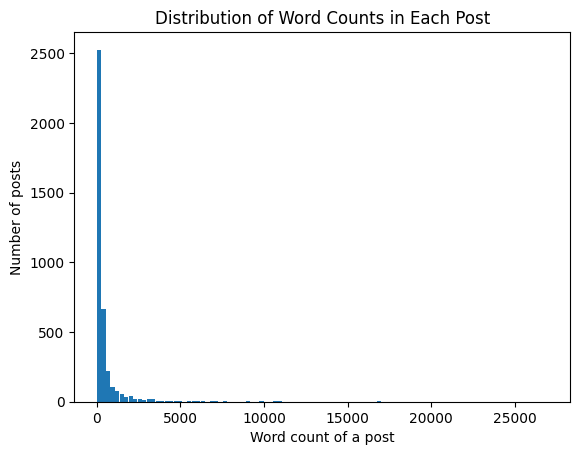

In [41]:
# check the word count distribution of the posts
plt.hist(df_post['length'].sort_values().values, bins=100, rwidth=0.9)
plt.xlabel("Word count of a post")
plt.ylabel("Number of posts")
plt.title("Distribution of Word Counts in Each Post")

In [42]:
# based on the distribution of word counts, we remove samples with word counts >= 6500
df_post = df_post[df_post['length'] < 6500]
df_post.shape

(3874, 5)

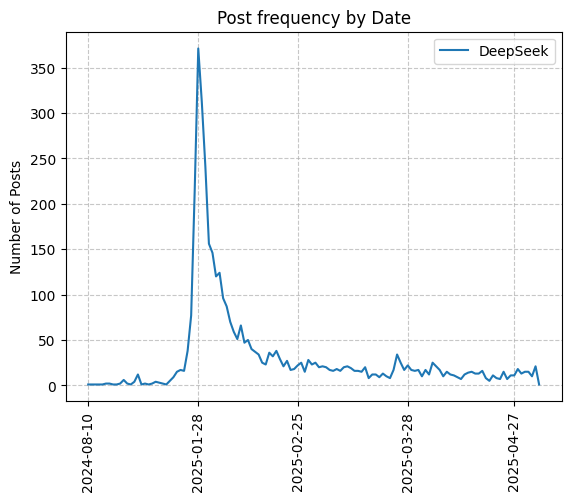

In [43]:
# visualize the post frequency
df_group = df_post.groupby(['date'])
df_bydate = df_group['post'].count().reset_index()

plt.plot(df_bydate['date'], df_bydate['post'], marker=None, linestyle='-', label='DeepSeek')

plt.title('Post frequency by Date')
plt.ylabel('Number of Posts')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# symplify the x labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# rotate tickers
plt.xticks(rotation=90)
plt.show()

**Discussion Q0**: Based on the plot, there's a noticeable peak in the post frequency. Can you explain why this occurred? (hint: Consider relevent developments in AI around that period).

(Your answer here)
Around 1/28/2025, Deepseek demonstrated strong reasoning abilities at a much lower cost compared to the US competitiors. Thus, there are more posts discussing DeepSeek on its impact on US chip and AI market, as well as its safety and ethics.

# Tasks to complete
In the previous section, we load and clean our Reddit posts before exploring the word counts distribution of the posts. In the following section, we will apply two different unsupervised learning methods to cluster the posts and identify hidden topics, and apply a pretrained supervised learning model to predict public emotions. Recall the difference between supervised and unsupervised learning:
- In supervised learning, we train the model with labeled data, and then apply the model to predict labels for future data;
- In unsupervised learning, we work with unlabled data, aiming to identify hidden patterns or underlying structures of the data.

# Task-1: K-Means Clustering

In this task, you will apply k-means clustering to group the posts into clusters. Specifically, you will:
- Represent each post with a vector (e.g. by using `CountVectorizer`, `TfidfVectorizer`, an OpenAI embedding, or other strategies);
- Fit K-means models for each of a range of possible k's (e.g. `for k in range(2, 10)`), and calculate the `mean_squared_error` (MSE) for each fitted model;
  - Recall that the `MSE` for each cluster is calculated as hte average difference between the cluster center and each data point in the cluster
  - Additionally recall that the `MSE` for the K-means model overall is the average MSE of all the generated clusters
- Visualize how the MSE changes with k (as in the example plot below). Identify **elbow points** fom the plot, and explain the best k in context of the given task.


Here is an example MSE plot.

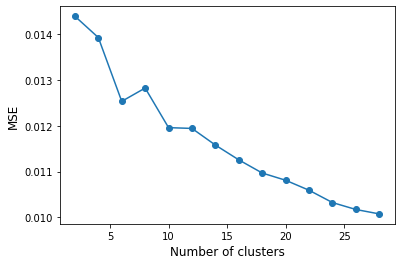

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

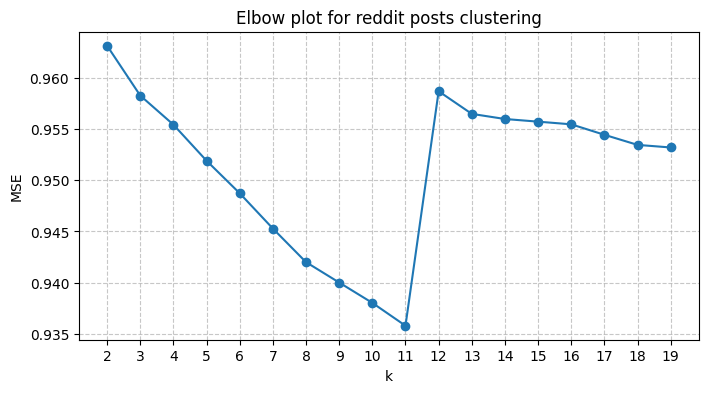

In [45]:
# Convert posts to numeric vectors using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df_post['post'])

# try a range of k values and record the mean squared error
ks = range(2, 20)
mse_list = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    mse = km.inertia_ / X.shape[0]
    mse_list.append(mse)

# plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(ks, mse_list, marker='o')
plt.xlabel('k')
plt.ylabel('MSE')
plt.title('Elbow plot for reddit posts clustering')
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**Discussion Q1: Explain the selected k in the context of the given task.** That is, which value of k would you choose based on the produced plot?  Why do you select that k? What does this mean in the context of our Reddit posts?

(Your answer here)

I would choose k=11. MSE steadily decreases from k=2 to 11, and the curve stopped decreasing at k =11 and jumps up sharply to k=12. It suggests that the meaningful structure has been captured by 11 clusters.

# Task-2: Sentiment Analysis

In this task, you will conduct sentiment analysis to examine user emotions toward when discussing DeepSeek on Reddit. You can choose to do it with [`vader SentimentIntensityAnalyzer`](https://github.com/cjhutto/vaderSentiment) or [`SamLowe/roberta-base-go_emotions`](https://huggingface.co/SamLowe/roberta-base-go_emotions).


If you choose to apply `vader SentimentIntensityAnalyzer`, then you need to do two broad steps:
1. Preprocess each post:
  - Remove English stopwords;
  - lemmatize each token;
  - Create a joint string of lemmatized tokens;
2. Run the model:
  - Initialize the `SentimentIntensityAnalyzer`;
  - Calculate the `polarity_score` of each processed post;
  - Extract the `compound` field from the `polarity_score` and record them in the new field `vader_sentiment`.

If you choose `SamLowe/roberta-base-go_emotions`, the specific steps are:
1. Apply `transformers.pipeline` to initialize a sentiment classifier from the model `SamLowe/roberta-base-go_emotions`, and apply it to predict emotions (note: the maximum text length the model can process is 514);
2. Record the 28 emotions and corresponding scores in the new field `roberta_multi_scores`;
3. Extract the emotions with a score >= 0.3, and record them in the new field `roberta_emotions`;
4. Save all the emotions in a list, sort the emotions by frequency descending order.



**Regardless of which model you apply, after conducting the sentiment analysis**, please:
1. Plot the sentiment distribution
  - If using the `roberta` model, this can be a bar plot; if using `vader`, this can be a density plot.
2. Visualize the sentiment change over time;
3. Discuss the sentiment distribution and sentiment change over time in the context of the given task.

Examples of all visuals can be seen below.

Example sentiment distribution plot using **Vader**:

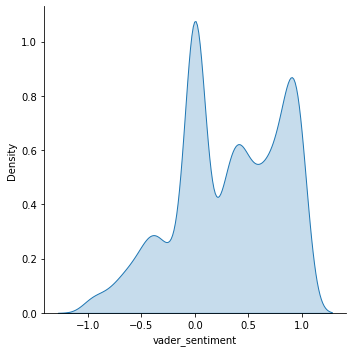

Example sentiment distribution plot using **Roberta**:

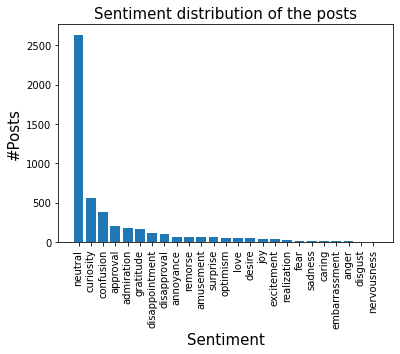

Example plot for **sentiment change over time**:

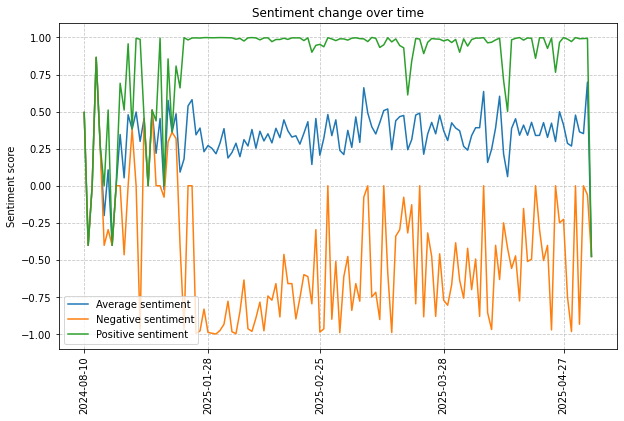

In [46]:
## Uncomment the relevant imports from below.
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

## Libraries you will need if using Roberta
import transformers

print(transformers.__version__)

4.57.6


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [47]:
# Your Code, Here!
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_vader(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)
df_post["preprocessed_post"] = df_post['post'].apply(preprocess_vader)




In [48]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df_post['vader_sentiment'] = df_post['preprocessed_post'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


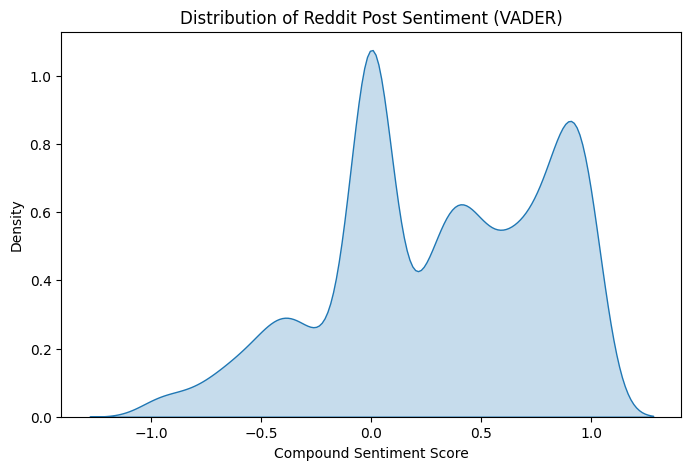

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(df_post['vader_sentiment'], fill=True)
plt.title("Distribution of Reddit Post Sentiment (VADER)")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Density")
plt.show()

In [50]:
def get_vader_scores(text):
    scores = sia.polarity_scores(text)
    return pd.Series({
        'vader_neg': scores['neg'],
        'vader_neu': scores['neu'],
        'vader_pos': scores['pos'],
        'vader_compound': scores['compound']
    })

df_post[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = \
    df_post['preprocessed_post'].apply(get_vader_scores)

<Figure size 1000x500 with 0 Axes>

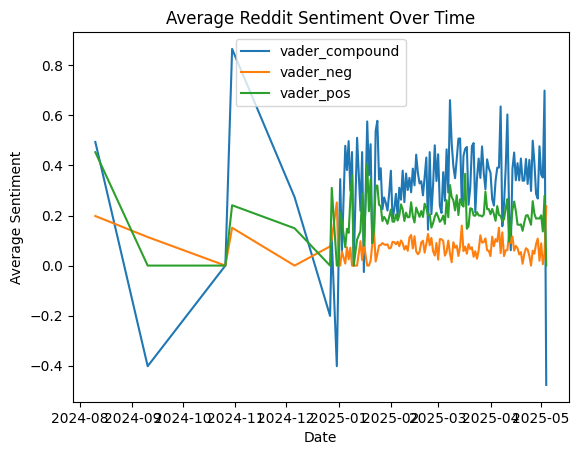

In [52]:
df_post['date'] = pd.to_datetime(df_post['date'])
df_post['date_only'] = df_post['date'].dt.date
daily_sentiment = df_post.groupby('date_only')[[
    'vader_compound',
    'vader_neg',
    'vader_pos'
]].mean()
plt.figure(figsize=(10,5))
daily_sentiment.plot()
plt.title("Average Reddit Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.show()

**Discussion Q2: What do you conclude from the sentiment distribution and sentiment change over time?**

(Your answer here)

The compound sentiment scores are generally above zero, which shows that most Reddit posts are positive. The positive scores are generally around 0.2 with some fluctuations before 2025-02. The negative score is present, but stays lower compared to positive sentiment scores across time.

The tone is stable after around 2025-02 at a slightly positive position, when DeepSeek became a hot topic on Reddit. There are also some sharp decreases, reflecting short-term controversies. Overall, it shows that the community is generally neutral and supportive without polarized emotions.

# Task-3: Topic analysis with LDA

In this task, you will perform LDA topic modeling to uncover latent topics on the `r/DeepSeek` subreddit. Specifically, you will:
- Clean the text by removing stopwords, punctuations, and normalize with WordNetLemmatizer;
- Represent each post as a list of tokens;
- Create a dictionary and document-term matrix;
- Fit a LDA model with `num_topics = 3`;
- Print the keywords for each topic;
- Visualize the topic distribution with `pyLDAvis` and interprete the visualization;
- Try different number of topics (e.g., `start=2, limit=40, step=3`), and calculate topic coherence of each model;
- Visualize the change of coherence score with the number of topics and identify the number of topics that gives the best coherence score;
- Re-fit the LDA model with the best number of topics, visualize the topic distribution, and interpete the visualization;

***Note:*** We have example visualizations below, but they are *very* fragile, and will disappear if the "run all" button is clicked in your notebook.

In [ ]:
# In order to successfully run LDA, make sure the following packages satisfy the version requirement
# pyLDAvis >= 3.4.0
# pandas < 2.0 # pip install pandas==1.5.3
# gensim >= 4.0


In [ ]:

from gensim import corpora
from gensim.models import LdaModel
import string
from pprint import pprint

import pyLDAvis
pyLDAvis.enable_notebook()

import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel
print(pyLDAvis.__version__)

warnings.filterwarnings('ignore', category=DeprecationWarning)

Found existing installation: pyLDAvis 3.4.0
Uninstalling pyLDAvis-3.4.0:
  Successfully uninstalled pyLDAvis-3.4.0
  Using cached pyLDAvis-3.4.1-py3-none-any.whl.metadata (4.2 kB)
Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
3.4.0


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/xiaohanwen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Topics for k=3:
Topic 0: 0.021*"like" + 0.011*"time" + 0.011*"know" + 0.010*"one" + 0.010*"get" + 0.009*"use" + 0.008*"even" + 0.008*"think"
Topic 1: 0.019*"china" + 0.011*"human" + 0.008*"would" + 0.008*"world" + 0.006*"like" + 0.006*"could" + 0.005*"let" + 0.004*"time"
Topic 2: 0.025*"model" + 0.012*"data" + 0.009*"use" + 0.008*"open" + 0.007*"would" + 0.007*"free" + 0.006*"source" + 0.006*"new"
k=2, c_v coherence=0.4042
k=5, c_v coherence=0.4581
k=8, c_v coherence=0.3517
k=11, c_v coherence=0.3313
k=14, c_v coherence=0.3475
k=17, c_v coherence=0.3598
k=20, c_v coherence=0.3495
k=23, c_v coherence=0.3538
k=26, c_v coherence=0.3389
k=29, c_v coherence=0.3579
k=32, c_v coherence=0.3869
k=35, c_v coherence=0.4050
k=38, c_v coherence=0.4107


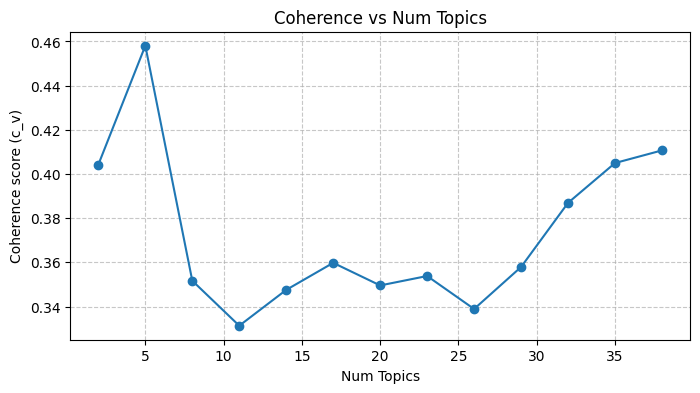

best_k based on c_v coherence: 5
Topics for best_k=5:
Topic 0: 0.039*"like" + 0.017*"would" + 0.013*"free" + 0.012*"way" + 0.012*"good" + 0.012*"make" + 0.011*"even" + 0.011*"want"
Topic 1: 0.019*"let" + 0.019*"one" + 0.019*"question" + 0.018*"answer" + 0.016*"thought" + 0.014*"time" + 0.013*"step" + 0.011*"word"
Topic 2: 0.032*"model" + 0.016*"data" + 0.011*"open" + 0.008*"source" + 0.008*"use" + 0.007*"support" + 0.007*"run" + 0.007*"new"
Topic 3: 0.027*"china" + 0.013*"human" + 0.011*"world" + 0.006*"self" + 0.006*"speech" + 0.006*"control" + 0.005*"quantum" + 0.005*"social"
Topic 4: 0.015*"anyone" + 0.015*"use" + 0.014*"chat" + 0.014*"get" + 0.014*"time" + 0.013*"server" + 0.012*"code" + 0.012*"know"


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.076920 -0.266403       1        1  25.412158
0     -0.171365 -0.044283       2        1  22.034043
4     -0.156235 -0.033149       3        1  21.596720
3      0.347314  0.092241       4        1  18.861263
1     -0.096634  0.251594       5        1  12.095817, topic_info=           Term         Freq        Total Category  logprob  loglift
73        model  1026.000000  1026.000000  Default  30.0000  30.0000
167       china   643.000000   643.000000  Default  29.0000  29.0000
68         like  1423.000000  1423.000000  Default  28.0000  28.0000
136        data   526.000000   526.000000  Default  27.0000  27.0000
5        anyone   421.000000   421.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
30       prompt   151.871424   447.200679   Topic5  -4.6157   1.0323
661       value    95.391680   141.744765   Topic5  -5.0808   1.7163
611   different   115.706536   299.119515   Topic5  -4.8877   1.1625
660        user   119.856273   349.141643   Topic5  -4.8525   1.0431
1944     simple   104.056713   221.419272   Topic5  -4.9938   1.3572

[284 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
606       3  0.994059      able
103       3  0.988308   account
460       4  0.997059       act
38        2  0.753994  actually
38        5  0.244539  actually
...     ...       ...       ...
94        1  0.273047     would
94        2  0.564298     would
94        3  0.024271     would
94        4  0.138344     would
227       5  0.990897     wrong

[391 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 5, 4, 2])

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
punctuations = set(string.punctuation)

def tokenize(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and t not in punctuations and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

tokenized_posts = [tokenize(p) for p in df_post['post']]

dictionary = corpora.Dictionary(tokenized_posts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in tokenized_posts]

lda3 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, random_state=42, passes=10, chunksize=100, per_word_topics=True)

print("Topics for k=3:")
for tid, topic in lda3.print_topics(num_words=8):
    print(f"Topic {tid}: {topic}")

pyLDAvis.enable_notebook()
vis3 = gensimvis.prepare(lda3, corpus, dictionary)
vis3

coherences = []
topic_range = range(2, 41, 3)

for k in topic_range:
    model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10, chunksize=100)
    cm = CoherenceModel(model=model, texts=tokenized_posts, dictionary=dictionary, coherence='c_v')
    coherences.append(cm.get_coherence())
    print(f"k={k}, c_v coherence={coherences[-1]:.4f}")

plt.figure(figsize=(8,4))
plt.plot(list(topic_range), coherences, marker='o')
plt.xlabel('Num Topics')
plt.ylabel('Coherence score (c_v)')
plt.title('Coherence vs Num Topics')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

best_idx = int(np.argmax(coherences))
best_k = list(topic_range)[best_idx]
print("best_k based on c_v coherence:", best_k)

lda_best = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k, random_state=42, passes=10, chunksize=100)

print(f"Topics for best_k={best_k}:")
for tid, topic in lda_best.print_topics(num_words=8):
    print(f"Topic {tid}: {topic}")

vis_best = gensimvis.prepare(lda_best, corpus, dictionary)
vis_best

**Discussion Q3.1: according to the plot, identify the optimal number of topics for the given task, and provide your explaination.**

(Your answer here)

The coherence score is the highest at k=5. It indicates that the model has the most semantically coherent output at the number of topics of 5.

Apply the chosen **best number of topics to re-fit LDA**, visualize & explore it here.

**Discussion Q3.2: Based on the generated plots, characterize the topic distribution. What do the keywords for each topic tell us about the topics? If you had to assign names to the topics, what would they be? Lastly, what do the observed topic distributions tell us about the r/DeepSeek subreddit?**

(Your answer here)

Topic 0: like, would, free, way, good, make, even, want
Name: General Opinions
This topic represents the general opinions and impressions of DeepSeek.

Topic 1: let, one, question, answer, thought, time, step, word
Name: Reasoning
This topic represent questions and reasoning processes. Words like "question", "answer", and "thought" suggest discussions about how the model reasons and responds.

Topic 2: model, data, open, source, use, support, run, new
Name: Technical
This topic is more about technical discussions on the model development. The words reflects the deployment and technical abilities of the model.

Topic 3: china, human, world, self, speech, control, quantum, social
Name: Geopolitical
This topic is more geopolitical and suggests discussion about AI's societal impact, as well as political considerations of DeepSeek.

Topic 4: anyone, use, chat, get, time, server, code, know
Name: Troubleshooting
This topic represents the discusssions during practical usage. The words suggest that the users are troubleshotting and asking for help on Reddit.

Based on the coherence analysis, the optimal number of topics is 5. The intertopic distance map also shows that the topics are well separated except topics 2 and 3 (may be due to the similarity of word distribution). The bubble sizes also appear balanced, meaning that there's no single topic dominating the subreddit.

Overall, the topic distribution indicates that the subreddit serves as 1. a technical forum, 2. a space for broader AI-related topics (political and societal), and 3. a place where users seek help. It also reflects that DeepSeek is multifaceted, with the nature of being a technical tool and a societal phenomenon. 

# Conclusion

In this assignment, we apply two different unsupervised learning methods to cluster the posts (`K-means`) and identify hidden topics (`LDA`), and apply a pretrained supervised learning model to predict public emotions (sentiment classifier).

Through these text analysis methods, we gain insights into users' opinions, usage, and deployment of AI. The identified insights could guide product designers, researchers, and software engineers seeking to find new and relevant use cases for LLMs.

Beyond the example exploration in this jupyter notebook, you can **extend it** in multiple different ways. For example:
- Compare sentiment and topic trends between posts and comments to see if they align or diverge.
- Analyze public perceptions of different AI innovations: examine how discussion topics and sentiments vary across different techniques.
- Explore additional dimensions such as temporal trends or emerging controversies to analyze the data.

Feel free to build on this foundation and uncover deeper insights.